# Nonlinear IV With Conditional Moment Restrictions

This notebook is a self-contained introduction to nonlinear instrumental variables (IV) through the same nonparametric IV data-generating process used in the `conditional-moment-restrictions` demo. The goal is to recover the structural function

$$f_0(x) = 2\log(|x| + 0.5)$$

when treatment $X$ is endogenous because an unobserved confounder $U$ affects both $X$ and $Y$. The instrument $Z$ shifts $X$ but has no direct effect on $Y$.

The key restriction is not an ordinary regression condition. It is the conditional moment restriction

$$E[Y - f_0(X) \mid Z] = 0.$$

Linear IV/2SLS is built for linear $f_0$. In this notebook the first stage is strong, but a line is the wrong structural class. The nonlinear CMR estimators use flexible neural structural functions and penalize violations of the conditional moment restriction.

## Short Reading Map

This notebook deliberately implements only the small, dependency-light pieces that fit Trex: kernel maximum moment restriction (MMR), polynomial sieve minimum distance (SMD), and plain PyTorch optimization. These papers are useful crash courses for the broader nonlinear-IV/CMR family:

- [Deep IV: A Flexible Approach for Counterfactual Prediction](https://proceedings.mlr.press/v70/hartford17a.html) estimates a flexible treatment first stage and trains a second-stage response model with the induced treatment distribution.
- [Deep Generalized Method of Moments for Instrumental Variable Analysis](https://papers.nips.cc/paper/8615-deep-generalized-method-of-moments-for-instrumental-variable-analysis) introduces DeepGMM, a variational GMM approach for many learned moments.
- [The Variational Method of Moments](https://academic.oup.com/jrsssb/article/85/3/810/7146121) gives a general minimax view of conditional moment estimation.
- [Functional Generalized Empirical Likelihood Estimation for Conditional Moment Restrictions](https://proceedings.mlr.press/v162/kremer22a.html) develops a GEL-style functional formulation for CMRs.
- [Estimation Beyond Data Reweighting: Kernel Method of Moments](https://proceedings.mlr.press/v202/kremer23a.html) replaces pure data reweighting with an MMD/KMM construction and includes conditional moment variants.

The estimators below are not a full reimplementation of those papers. They are a compact Trex-native starting point for empirical work: clean PyTorch, explicit estimator semantics, no DeepGMM/MOSEK/CVXPY/RFF dependency stack.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from trex import MaximumMomentRestriction, SieveMinimumDistance
from trex.cmr import hsic, mmr_loss

torch.set_num_threads(1)
np.random.seed(42)
_ = torch.manual_seed(42)

## Data-Generating Process

The DGP follows the CMR repository's `demo_all_methods.py`:

$$U \sim N(0, 1), \quad Z \sim \operatorname{Uniform}(-3, 3)$$

$$X = Z + U + \epsilon_x$$

$$Y = 2\log(|X| + 0.5) + U + \epsilon_y.$$

Because $U$ enters both $X$ and $Y$, ordinary regression of $Y$ on $X$ learns a mixture of the structural relationship and selection on unobservables. Because $Z$ is independent of $U$ and excluded from the outcome, the structural residual should have zero conditional mean given $Z$.

In [2]:
def true_structural_function(x):
    return 2.0 * np.log(np.abs(x) + 0.5)


def generate_nonparametric_iv_data(n, seed):
    rng = np.random.default_rng(seed)
    u = rng.normal(0.0, 1.0, size=(n, 1)).astype("float32")
    z = rng.uniform(-3.0, 3.0, size=(n, 1)).astype("float32")
    eps_x = rng.normal(0.0, 0.1, size=(n, 1)).astype("float32")
    eps_y = rng.normal(0.0, 0.1, size=(n, 1)).astype("float32")
    x = z + u + eps_x
    y = true_structural_function(x).astype("float32") + u + eps_y
    return {"t": x, "y": y, "z": z, "u": u}


train = generate_nonparametric_iv_data(500, seed=42)
test = generate_nonparametric_iv_data(2000, seed=44)

t_train = torch.tensor(train["t"])
y_train = torch.tensor(train["y"])
z_train = torch.tensor(train["z"])

x_grid = np.linspace(
    np.percentile(test["t"], 1),
    np.percentile(test["t"], 99),
    300,
    dtype="float32",
)[:, None]
x_grid_t = torch.tensor(x_grid)
f_grid = torch.tensor(true_structural_function(x_grid).astype("float32"))

print(f"train n={len(t_train)}, test n={len(test['t'])}")
print(f"corr(X, U)={np.corrcoef(train['t'].ravel(), train['u'].ravel())[0, 1]:.3f}")
print(f"corr(Z, U)={np.corrcoef(train['z'].ravel(), train['u'].ravel())[0, 1]:.3f}")

train n=500, test n=2000
corr(X, U)=0.473
corr(Z, U)=-0.007


## What Linear IV Does Here

It is useful to benchmark against plain linear OLS and linear 2SLS:

$$Y = \alpha + \beta X + \varepsilon, \quad X = \pi_0 + \pi_1 Z + \eta.$$

The first stage is strong in this simulation, so linear IV has no weak-instrument excuse. It enforces the unconditional instrument moment $E[Z(Y-\alpha-\beta X)] = 0$, but it still searches only over lines. Since $f_0$ is U-shaped, the linear IV fit becomes almost flat: it makes the residual orthogonal to $Z$ but does not recover the nonlinear structural curve.

In [3]:
def fit_linear_ols_and_iv(x, y, z):
    design_x = np.c_[np.ones(len(x)), x]
    design_z = np.c_[np.ones(len(z)), z]

    beta_ols = np.linalg.lstsq(design_x, y, rcond=None)[0]

    projection_z = design_z @ np.linalg.inv(design_z.T @ design_z) @ design_z.T
    beta_iv = np.linalg.inv(design_x.T @ projection_z @ design_x) @ design_x.T @ projection_z @ y

    first_stage = np.linalg.lstsq(design_z, x, rcond=None)[0]
    fitted_x = design_z @ first_stage
    ssr = np.sum((x - fitted_x) ** 2)
    sst = np.sum((x - np.mean(x)) ** 2)
    r_squared = 1.0 - ssr / sst
    n_obs, n_first_stage_params = design_z.shape
    f_stat = (r_squared / (n_first_stage_params - 1)) / ((1.0 - r_squared) / (n_obs - n_first_stage_params))

    return beta_ols, beta_iv, first_stage, r_squared, f_stat


linear_ols_beta, linear_iv_beta, first_stage_beta, first_stage_r2, first_stage_f = fit_linear_ols_and_iv(
    train["t"], train["y"], train["z"]
)

ols_resid = train["y"] - np.c_[np.ones(len(train["t"])), train["t"]] @ linear_ols_beta
iv_resid = train["y"] - np.c_[np.ones(len(train["t"])), train["t"]] @ linear_iv_beta

print(f"linear OLS: Y = {linear_ols_beta[0, 0]:.3f} + {linear_ols_beta[1, 0]:.3f} X")
print(f"linear IV:  Y = {linear_iv_beta[0, 0]:.3f} {linear_iv_beta[1, 0]:+.3f} X")
print(f"first stage: X = {first_stage_beta[0, 0]:.3f} + {first_stage_beta[1, 0]:.3f} Z")
print(f"first-stage R^2={first_stage_r2:.3f}, F={first_stage_f:.1f}")
print(f"corr(OLS residual, Z)={np.corrcoef(ols_resid.ravel(), train['z'].ravel())[0, 1]:.3f}")
print(f"corr(IV residual, Z)={np.corrcoef(iv_resid.ravel(), train['z'].ravel())[0, 1]:.3e}")

linear OLS: Y = 1.260 + 0.230 X
linear IV:  Y = 1.255 -0.011 X
first stage: X = -0.011 + 0.993 Z
first-stage R^2=0.768, F=1649.7
corr(OLS residual, Z)=-0.299
corr(IV residual, Z)=6.159e-17


## Nonlinear CMR Estimators

The residual moment is

$$\psi_\theta(X,Y) = f_\theta(X) - Y.$$

CMR estimation asks for this residual to have zero conditional expectation given $Z$. A common move is to convert the conditional restriction into many unconditional restrictions indexed by test functions $h$:

$$E[\psi_\theta(X,Y)h(Z)] = 0 \quad \text{for many } h.$$

The two Trex estimators here instantiate this idea simply:

- `MaximumMomentRestriction` uses an RBF kernel over $Z$ and minimizes a kernelized conditional moment violation.
- `SieveMinimumDistance` uses a polynomial basis in $Z$ and minimizes a quadratic form in the projected moments.

Both use the same neural structural model. To focus the comparison on the conditional-moment correction, the CMR models start from the neural least-squares fit and then update the network using their CMR objectives.

In [4]:
def make_network():
    return torch.nn.Sequential(
        torch.nn.Linear(1, 64),
        torch.nn.Tanh(),
        torch.nn.Linear(64, 32),
        torch.nn.Tanh(),
        torch.nn.Linear(32, 1),
    )


def residual_moment(prediction, y):
    return prediction - y


def train_least_squares(model, steps=1200, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        loss = torch.mean((model(t_train) - y_train).square())
        loss.backward()
        optimizer.step()
    return model


def clone_model(model):
    cloned = make_network()
    cloned.load_state_dict(model.state_dict())
    return cloned


ols_model = train_least_squares(make_network())

mmr = MaximumMomentRestriction(
    model=clone_model(ols_model),
    moment_function=residual_moment,
    optimizer=torch.optim.Adam,
    lr=2e-3,
    maxiter=1200,
    device="cpu",
)
_ = mmr.fit(t_train, y_train, z_train)

smd = SieveMinimumDistance(
    model=clone_model(ols_model),
    moment_function=residual_moment,
    optimizer=torch.optim.Adam,
    lr=2e-3,
    maxiter=1200,
    degree=5,
    device="cpu",
)
_ = smd.fit(t_train, y_train, z_train)

In [5]:
def linear_prediction(beta, x):
    return np.c_[np.ones(len(x)), x] @ beta


def evaluate_prediction(name, prediction_grid, prediction_train):
    grid_pred_t = torch.tensor(prediction_grid.astype("float32"))
    train_resid_t = torch.tensor((prediction_train - train["y"]).astype("float32"))
    return {
        "name": name,
        "grid_mse_to_true_f": torch.mean((grid_pred_t - f_grid).square()).item(),
        "mmr_loss": mmr_loss(train_resid_t, z_train).item(),
        "hsic_residual_z": hsic(train_resid_t, z_train).item(),
    }


def evaluate_model(name, model):
    with torch.no_grad():
        grid_pred = model(x_grid_t)
        train_resid = model(t_train) - y_train
    return {
        "name": name,
        "grid_mse_to_true_f": torch.mean((grid_pred - f_grid).square()).item(),
        "mmr_loss": mmr_loss(train_resid, z_train).item(),
        "hsic_residual_z": hsic(train_resid, z_train).item(),
    }


results = [
    evaluate_prediction(
        "Linear OLS",
        linear_prediction(linear_ols_beta, x_grid),
        linear_prediction(linear_ols_beta, train["t"]),
    ),
    evaluate_prediction(
        "Linear IV",
        linear_prediction(linear_iv_beta, x_grid),
        linear_prediction(linear_iv_beta, train["t"]),
    ),
    evaluate_model("Neural least squares", ols_model),
    evaluate_model("MMR", mmr.model),
    evaluate_model("Polynomial SMD", smd.model),
]

header = f"{'estimator':<22} {'grid MSE':>12} {'MMR loss':>12} {'HSIC':>12}"
print(header)
print("-" * len(header))
for row in results:
    print(
        f"{row['name']:<22} "
        f"{row['grid_mse_to_true_f']:>12.4f} "
        f"{row['mmr_loss']:>12.6f} "
        f"{row['hsic_residual_z']:>12.6f}"
    )

estimator                  grid MSE     MMR loss         HSIC
-------------------------------------------------------------
Linear OLS                   1.6143     0.124600     0.025407
Linear IV                    1.4548     0.075245     0.027820
Neural least squares         0.4849     0.031391     0.010570
MMR                          0.0476     0.000007     0.001178
Polynomial SMD               0.0891     0.000007     0.001983


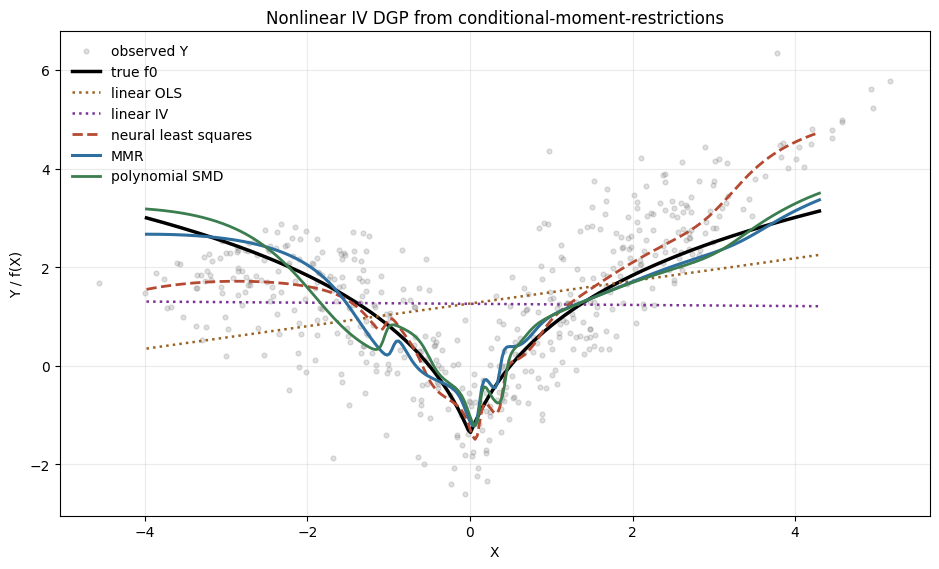

In [6]:
with torch.no_grad():
    pred_neural_ls = ols_model(x_grid_t).numpy()
    pred_mmr = mmr.predict(x_grid_t).numpy()
    pred_smd = smd.predict(x_grid_t).numpy()

pred_linear_ols = linear_prediction(linear_ols_beta, x_grid)
pred_linear_iv = linear_prediction(linear_iv_beta, x_grid)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
sample = np.random.default_rng(7).choice(len(test["t"]), size=500, replace=False)
ax.scatter(
    test["t"][sample],
    test["y"][sample],
    s=12,
    alpha=0.22,
    color="0.45",
    label="observed Y",
)
ax.plot(x_grid, true_structural_function(x_grid), color="black", lw=2.5, label="true f0")
ax.plot(x_grid, pred_linear_ols, color="#9a6324", lw=1.8, ls=":", label="linear OLS")
ax.plot(x_grid, pred_linear_iv, color="#7b3294", lw=1.8, ls=":", label="linear IV")
ax.plot(x_grid, pred_neural_ls, color="#b54a33", lw=2, ls="--", label="neural least squares")
ax.plot(x_grid, pred_mmr, color="#2f6f9f", lw=2.2, label="MMR")
ax.plot(x_grid, pred_smd, color="#3b7d4f", lw=2, label="polynomial SMD")
ax.set_title("Nonlinear IV DGP from conditional-moment-restrictions")
ax.set_xlabel("X")
ax.set_ylabel("Y / f(X)")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="best")
fig.tight_layout()

## Takeaway

Linear IV is doing exactly what its assumptions ask it to do: it uses the strong instrument to remove the linear projection of the endogenous component. In this DGP that is not enough. The identified object is a nonlinear structural function, and the conditional moment restriction is a much richer object than a single linear instrument moment.

The CMR fits are not magic either; they depend on model capacity, optimization, sample size, and how the conditional restriction is approximated. But they target the right problem class: flexible $f_\theta$ subject to residual variation that should not be predictable from $Z$.